# Clasificarea categoriilor de produse

## Machine Learning Project

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pickle

pd.set_option("display.max_columns", None)

### Încărcarea datasetului

In [79]:
df = pd.read_csv("products.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (35311, 8)


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


In [80]:
print("Columns:")
print(df.columns.tolist())

Columns:
['product ID', 'Product Title', 'Merchant ID', ' Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', ' Listing Date  ']


### Eliminăm spațiile inutile din numele coloanelor

In [81]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


### Verificarea structurii

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35311 entries, 0 to 35310
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product ID       35311 non-null  int64  
 1   Product Title    35139 non-null  object 
 2   Merchant ID      35311 non-null  int64  
 3   Category Label   35267 non-null  object 
 4   _Product Code    35216 non-null  object 
 5   Number_of_Views  35297 non-null  float64
 6   Merchant Rating  35141 non-null  float64
 7   Listing Date     35252 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.2+ MB


In [83]:
df.describe(include="all")

,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
count,35311.000000,35139,35311.000000,35267,35216,35297.000000,35141.000000,35252
unique,NaN,30860,NaN,13,35216,NaN,NaN,1096
top,NaN,washing machine,NaN,Fridge Freezers,WU-5686-LX,NaN,NaN,8/5/2024
freq,NaN,90,NaN,5495,1,NaN,NaN,53
mean,26150.800176,NaN,120.501883,NaN,NaN,2501.469587,2.998261,NaN
std,13498.191220,NaN,117.045557,NaN,NaN,1438.217697,1.152664,NaN
min,1.000000,NaN,1.000000,NaN,NaN,0.000000,1.000000,NaN
25%,14958.500000,NaN,17.000000,NaN,NaN,1256.000000,2.000000,NaN
50%,27614.000000,NaN,75.000000,NaN,NaN,2509.000000,3.000000,NaN
75%,37508.500000,NaN,253.000000,NaN,NaN,3735.000000,4.000000,NaN


In [84]:
print("Valori lipsă:")
print(df.isnull().sum())

print("\nDuplicate:")
print(df.duplicated().sum())

Valori lipsă:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

Duplicate:
0


### Verificăm distribuția categoriilor

In [85]:
print("Numărul de categorii:", df["Category Label"].nunique())

print("\nCategorii:")
print(df["Category Label"].value_counts())

Numărul de categorii: 13

Categorii:
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


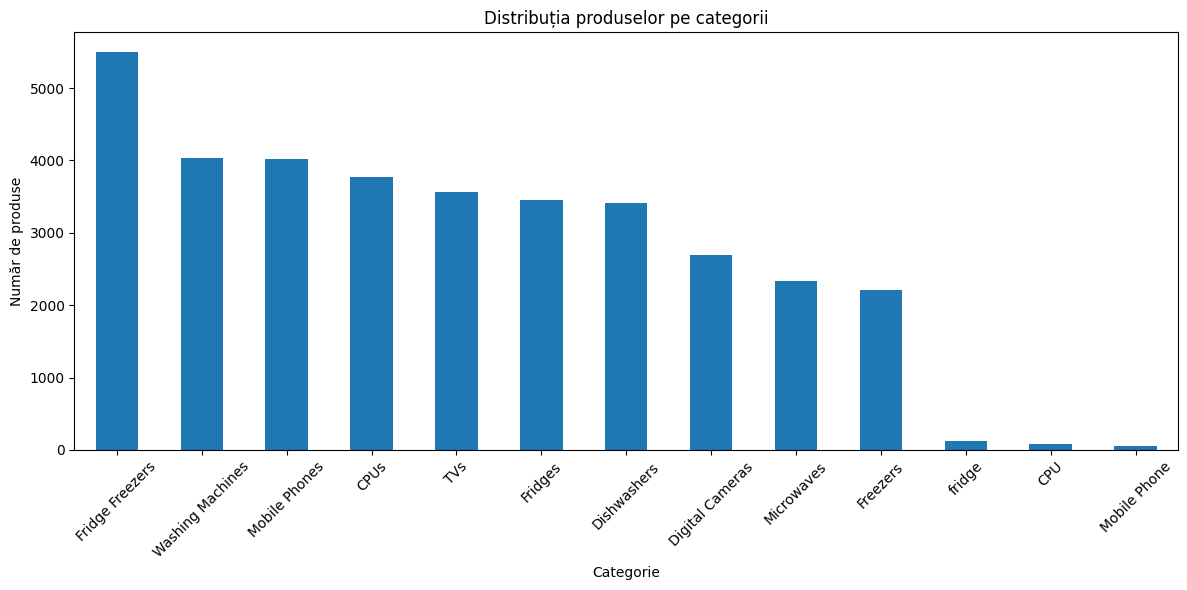

In [86]:
plt.figure(figsize=(12, 6))

df["Category Label"].value_counts().plot(kind="bar")

plt.title("Distribuția produselor pe categorii")
plt.xlabel("Categorie")
plt.ylabel("Număr de produse")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Verificarea datelor produselor

In [87]:
df[
    [
        "Product Title",
        "Category Label",
        "Number_of_Views",
        "Merchant Rating",
        "Listing Date"
    ]
].head(10)

,Product Title,Category Label,Number_of_Views,Merchant Rating,Listing Date
0,apple iphone 8 plus 64gb silver,Mobile Phones,860.0,2.5,5/10/2024
1,apple iphone 8 plus 64 gb spacegrau,Mobile Phones,3772.0,4.8,12/31/2024
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,Mobile Phones,3092.0,3.9,11/10/2024
3,apple iphone 8 plus 64gb space grey,Mobile Phones,466.0,3.4,5/2/2022
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones,4426.0,1.6,4/12/2023
5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,Mobile Phones,3444.0,1.6,11/27/2022
6,apple iphone 8 plus 64 gb space grey,Mobile Phones,3171.0,1.2,3/29/2022
7,apple iphone 8 plus 64gb space grey,Mobile Phones,2919.0,4.5,5/21/2024
8,apple iphone 8 plus 64gb space grey,Mobile Phones,130.0,3.4,5/11/2022
9,apple iphone 8 plus 64gb space grey,Mobile Phones,1685.0,3.8,2/9/2024


### Curățarea titlurilor produselor

In [88]:
df["Product Title"] = (
    df["Product Title"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

df["Product Title"].head()

,Product Title
0,apple iphone 8 plus 64gb silver
1,apple iphone 8 plus 64 gb spacegrau
2,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...
3,apple iphone 8 plus 64gb space grey
4,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...


### Eliminarea rândurilor fără titlu sau categorie

In [89]:
df = df[
    (df["Product Title"] != "") &
    (df["Category Label"].notna())
].copy()

print("Dimensiunea datasetului după curățare:", df.shape)

Dimensiunea datasetului după curățare: (35096, 8)


### Eliminarea duplicatelor

In [90]:
print(
    "Duplicate înainte de eliminare:",
    df.duplicated().sum()
)

df = df.drop_duplicates().copy()

print(
    "Dimensiunea datasetului după eliminarea duplicatelor:",
    df.shape
)

Duplicate înainte de eliminare: 0
Dimensiunea datasetului după eliminarea duplicatelor: (35096, 8)


### Transformarea datei

In [91]:
df["Listing Date"] = pd.to_datetime(
    df["Listing Date"],
    errors="coerce"
)

print(df["Listing Date"].head())

0   2024-05-10
1   2024-12-31
2   2024-11-10
3   2022-05-02
4   2023-04-12
Name: Listing Date, dtype: datetime64[ns]


In [92]:
df["Listing Year"] = df["Listing Date"].dt.year
df["Listing Month"] = df["Listing Date"].dt.month
df["Listing DayOfWeek"] = df["Listing Date"].dt.dayofweek

df[
    [
        "Listing Date",
        "Listing Year",
        "Listing Month",
        "Listing DayOfWeek"
    ]
].head()

,Listing Date,Listing Year,Listing Month,Listing DayOfWeek
0,2024-05-10,2024.0,5.0,4.0
1,2024-12-31,2024.0,12.0,1.0
2,2024-11-10,2024.0,11.0,6.0
3,2022-05-02,2022.0,5.0,0.0
4,2023-04-12,2023.0,4.0,2.0


### Analiza variabilelor numerice

In [93]:
numeric_columns = [
    "Number_of_Views",
    "Merchant Rating"
]

df[numeric_columns].describe()

,Number_of_Views,Merchant Rating
count,35082.000000,34926.00000
mean,2502.052249,2.99848
std,1438.466650,1.15228
min,0.000000,1.00000
25%,1256.000000,2.00000
50%,2511.000000,3.00000
75%,3736.000000,4.00000
max,5000.000000,5.00000


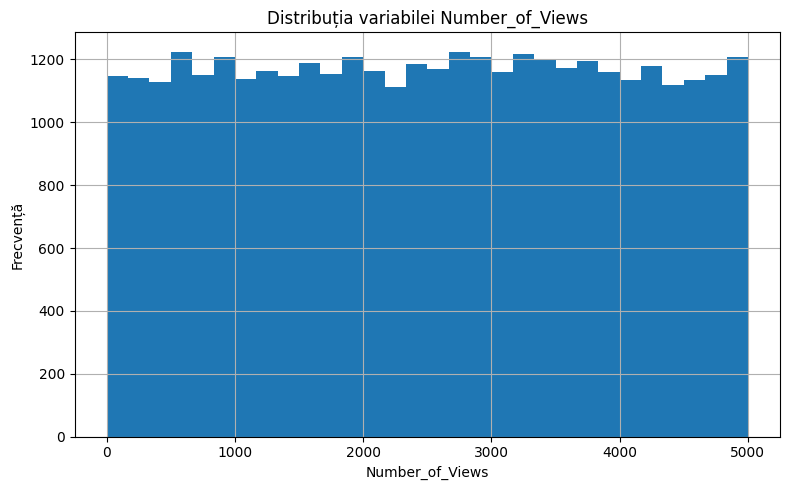

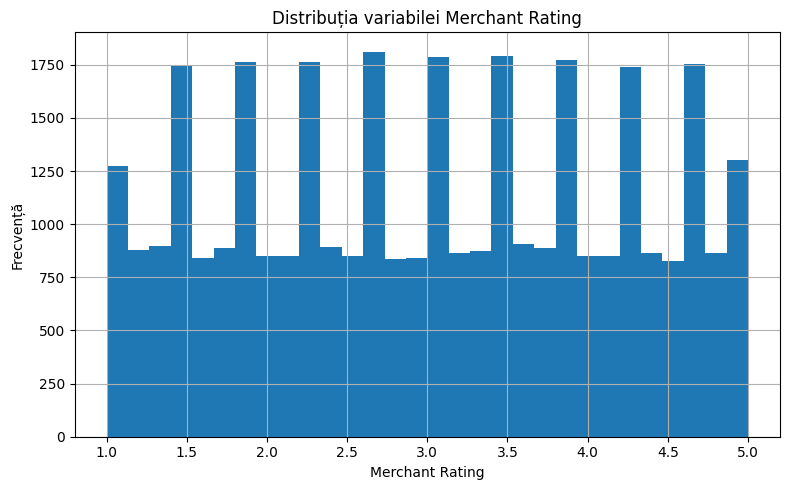

In [94]:
for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    df[column].hist(bins=30)

    plt.title(f"Distribuția variabilei {column}")
    plt.xlabel(column)
    plt.ylabel("Frecvență")

    plt.tight_layout()
    plt.show()

### Verificarea finală a datelor

In [95]:
print("Valori lipsă:")
print(df.isnull().sum())

print("\nTipurile de date:")
print(df.dtypes)

Valori lipsă:
product ID             0
Product Title          0
Merchant ID            0
Category Label         0
_Product Code         94
Number_of_Views       14
Merchant Rating      170
Listing Date          58
Listing Year          58
Listing Month         58
Listing DayOfWeek     58
dtype: int64

Tipurile de date:
product ID                    int64
Product Title                object
Merchant ID                   int64
Category Label               object
_Product Code                object
Number_of_Views             float64
Merchant Rating             float64
Listing Date         datetime64[ns]
Listing Year                float64
Listing Month               float64
Listing DayOfWeek           float64
dtype: object


### Pregătirea pentru Machine Learning

In [96]:
X = df["Product Title"]
y = df["Category Label"]

print("Numărul de produse:", len(X))
print("Numărul de categorii:", y.nunique())

Numărul de produse: 35096
Numărul de categorii: 13


### Împărțirea în date de antrenare și testare

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Produse pentru antrenare:", len(X_train))
print("Produse pentru testare:", len(X_test))

Produse pentru antrenare: 28076
Produse pentru testare: 7020


## Vectorizarea textului folosind TF-IDF

In [98]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

## Modelul 1: Logistic Regression

Primul model utilizat este Logistic Regression.

Modelul este potrivit pentru clasificarea textelor deoarece poate lucra
cu reprezentarea numerică obținută prin TF-IDF.

In [99]:
logistic_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Modelul Logistic Regression a fost antrenat.")

Modelul Logistic Regression a fost antrenat.


### Evaluarea Logistic Regression

In [100]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Rezultate Logistic Regression:")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Rezultate Logistic Regression:
Accuracy : 0.9523
Precision: 0.9465
Recall   : 0.9523
F1 Score : 0.9489


## Modelul 2: Multinomial Naive Bayes

Al doilea model este Multinomial Naive Bayes.

Acesta este un algoritm utilizat frecvent pentru clasificarea
documentelor și a textelor.

In [101]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", MultinomialNB())
])

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Modelul Multinomial Naive Bayes a fost antrenat.")

Modelul Multinomial Naive Bayes a fost antrenat.


### Evaluarea Naive Bayes

In [102]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

print("Rezultate Multinomial Naive Bayes:")
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")

Rezultate Multinomial Naive Bayes:
Accuracy : 0.9423
Precision: 0.9408
Recall   : 0.9423
F1 Score : 0.9389


## Compararea modelelor

Vom compara cele două modele folosind:
- Accuracy;
- Precision;
- Recall;
- F1 Score.

Modelul final va fi ales pe baza performanțelor obținute pe setul de testare.

In [103]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_nb
    ],
    "Precision": [
        precision_lr,
        precision_nb
    ],
    "Recall": [
        recall_lr,
        recall_nb
    ],
    "F1 Score": [
        f1_lr,
        f1_nb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.952279,0.946549,0.952279,0.948912
1,Multinomial Naive Bayes,0.942308,0.940837,0.942308,0.938851


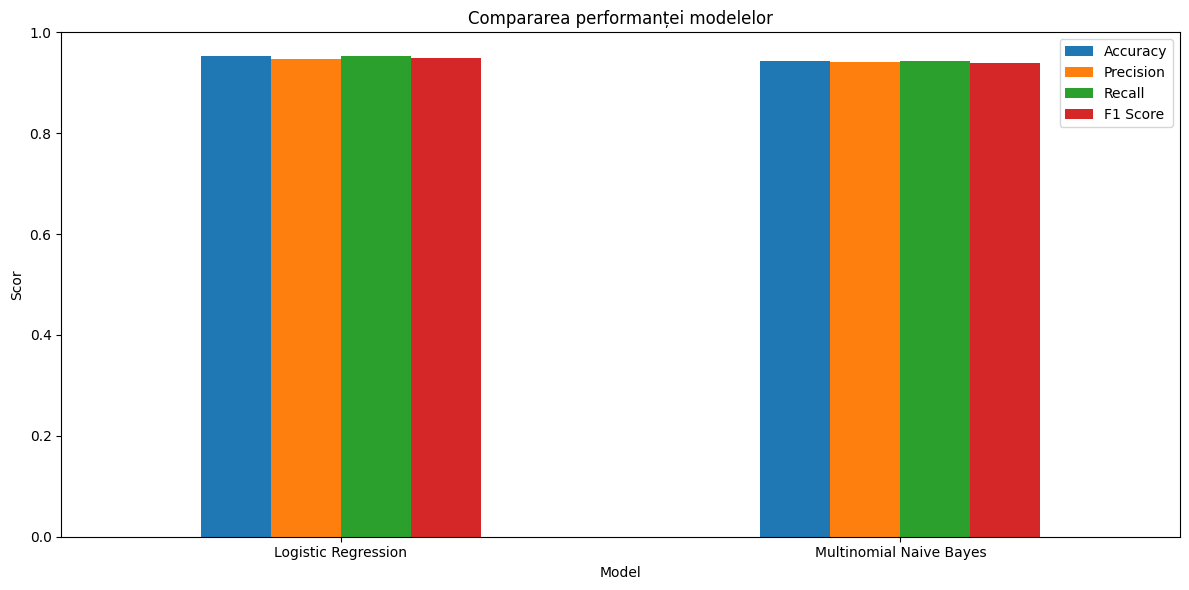

In [104]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Compararea performanței modelelor")
plt.xlabel("Model")
plt.ylabel("Scor")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Alegerea modelului

In [105]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Cel mai bun model:", best_model_name)

Cel mai bun model: Logistic Regression


In [106]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    y_pred_best = y_pred_lr
else:
    best_model = nb_model
    y_pred_best = y_pred_nb

print("Modelul final selectat:", best_model_name)

Modelul final selectat: Logistic Regression


## Raportul de clasificare

Raportul prezintă Precision, Recall și F1 Score pentru fiecare categorie.

In [107]:
print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

             CPU       0.00      0.00      0.00        17
            CPUs       0.98      1.00      0.99       749
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.98      0.91      0.95       681
        Freezers       0.99      0.92      0.96       440
 Fridge Freezers       0.90      0.96      0.93      1094
         Fridges       0.87      0.91      0.89       687
      Microwaves       0.99      0.96      0.98       466
    Mobile Phone       0.00      0.00      0.00        11
   Mobile Phones       0.95      0.99      0.97       801
             TVs       0.99      0.98      0.99       708
Washing Machines       0.96      0.95      0.95       803
          fridge       0.00      0.00      0.00        25

        accuracy                           0.95      7020
       macro avg       0.74      0.74      0.74      7020
    weighted avg       0.95      0.95      0.95      7020



## Matricea de confuzie

Matricea de confuzie ne permite să observăm ce categorii sunt clasificate
corect și între ce categorii apar confuzii.

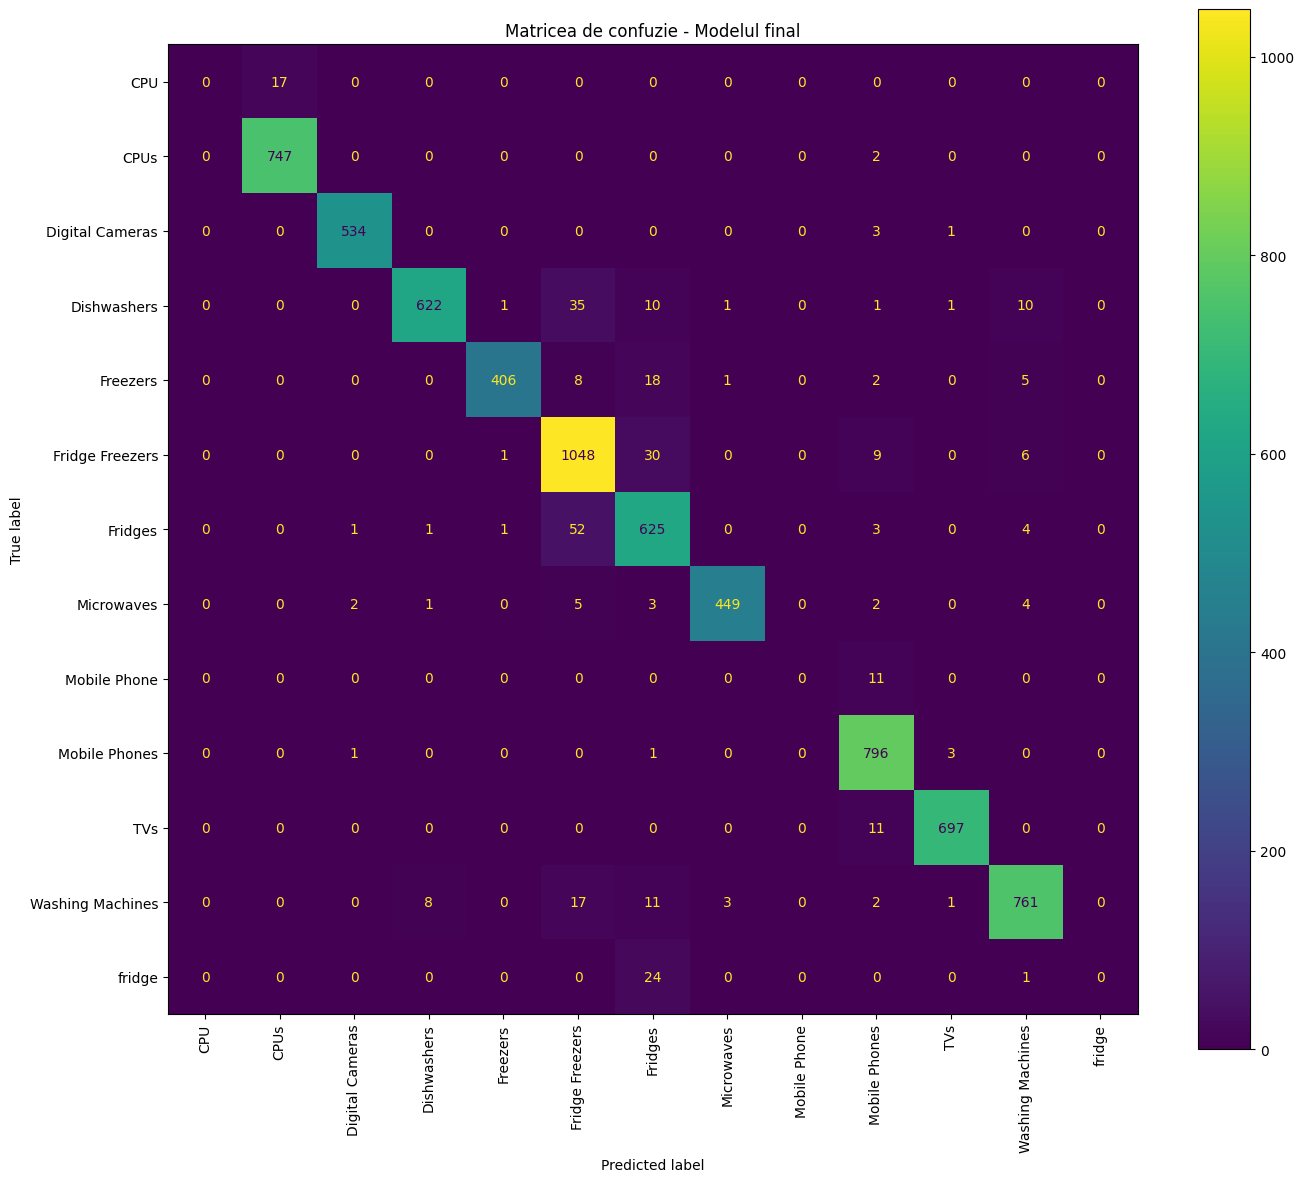

In [108]:
cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Matricea de confuzie - Modelul final")
plt.tight_layout()
plt.show()

## Salvarea modelului

Modelul final este salvat într-un fișier `.pkl`.

Deoarece folosim un Pipeline, atât vectorizarea TF-IDF, cât și
clasificatorul sunt salvate împreună.

In [109]:
with open("product_classifier.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Modelul a fost salvat în product_classifier.pkl")

Modelul a fost salvat în product_classifier.pkl


## Predicția categoriei pentru produse noi

In [110]:
produse_noi = [
    "apple iphone 15 pro max 256gb",
    "wireless bluetooth headphones",
    "men leather running shoes"
]

predictii = best_model.predict(produse_noi)

for produs, categorie in zip(produse_noi, predictii):
    print(f"Produs: {produs}")
    print(f"Categoria prezisă: {categorie}")
    print()

Produs: apple iphone 15 pro max 256gb
Categoria prezisă: Mobile Phones

Produs: wireless bluetooth headphones
Categoria prezisă: Mobile Phones

Produs: men leather running shoes
Categoria prezisă: Mobile Phones

